In [1074]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.gridspec import GridSpec
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import r_regression, f_regression
from sklearn.model_selection import train_test_split
from scipy.stats import f

In [1076]:
# Load dataset
df = pd.read_csv('data/Urban_Park_Ranger_Animal_Condition_Response.csv')
df.head()

,Date and Time of initial call,Date and time of Ranger response,Borough,Property,Location,Species Description,Call Source,Species Status,Animal Condition,Duration of Response,...,311SR Number,Final Ranger Action,# of Animals,PEP Response,Animal Monitored,Rehabilitator,Hours spent monitoring,Police Response,ESU Response,ACC Intake Number
0,06/23/2021 04:45:00 PM,06/24/2021 08:00:00 AM,Brooklyn,Sternberg Park,Inside locked athletic field under construction,Chukar,Other,Exotic,Healthy,6.00,...,311-06712416,ACC,6.0,False,False,NaN,NaN,False,False,163537
1,06/24/2021 10:00:00 AM,06/24/2021 11:00:00 AM,Bronx,Haffen Park,Haffen Pool,Sparrow,Central,Native,Healthy,1.75,...,311-06714879,Rehabilitator,4.0,False,False,NaN,NaN,False,False,NaN
2,06/23/2021 02:30:00 PM,06/23/2021 02:30:00 PM,Bronx,Pelham Bay Park,Pelham Bay South,White-tailed Deer,Employee,Native,NaN,1.00,...,NaN,Unfounded,0.0,False,False,NaN,NaN,False,False,NaN
3,06/23/2021 01:00:00 PM,06/23/2021 01:10:00 PM,Staten Island,Willowbrook Park,The carousel,Raccoon,Employee,Native,NaN,2.00,...,NaN,Unfounded,0.0,False,False,NaN,NaN,False,False,NaN
4,06/23/2021 09:20:00 AM,06/23/2021 09:20:00 AM,Queens,Judge Moses Weinstein Playground,Garbage can,Virginia Opossum,Central,Native,Healthy,2.25,...,311-06699415,ACC,1.0,False,False,NaN,NaN,False,False,119833


In [1078]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6385 entries, 0 to 6384
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Date and Time of initial call     6385 non-null   object 
 1   Date and time of Ranger response  6385 non-null   object 
 2   Borough                           6385 non-null   object 
 3   Property                          6384 non-null   object 
 4   Location                          6343 non-null   object 
 5   Species Description               6382 non-null   object 
 6   Call Source                       6385 non-null   object 
 7   Species Status                    6324 non-null   object 
 8   Animal Condition                  5685 non-null   object 
 9   Duration of Response              6385 non-null   float64
 10  Age                               6385 non-null   object 
 11  Animal Class                      6385 non-null   object 
 12  311SR 

In [1079]:
df.describe()

,Duration of Response,# of Animals,Hours spent monitoring
count,6385.000000,6381.000000,908.000000
mean,1.425792,1.315938,0.948899
std,1.597447,12.461735,1.857773
min,0.000000,0.000000,0.000000
25%,0.500000,1.000000,0.250000
50%,1.000000,1.000000,0.500000
75%,2.000000,1.000000,1.000000
max,75.000000,900.000000,48.000000


In [1081]:
cols_with_missing = pd.Series(['Species Description', 'Species Status', 'Animal Condition', 'Age', '# of Animals'])
#count number of '0' values for relevant columns. 
num_missing = (df[cols_with_missing] ==0).sum()
print(num_missing)

Species Description       0
Species Status            0
Animal Condition          0
Age                       0
# of Animals           1380
dtype: int64


In [1084]:
#replace '0' values with 'nan'. Don't need to do it because no values that are 0. 
df[cols_with_missing] = df[cols_with_missing].replace(0, np.nan)

In [1085]:
print(df[cols_with_missing].isnull().sum())
print (df.shape)

Species Description       3
Species Status           61
Animal Condition        700
Age                       0
# of Animals           1384
dtype: int64
(6385, 22)


In [1088]:
# drop nan values from relevant features.
df= df.dropna(subset=['Species Description','Species Status','Animal Condition','Duration of Response','Age', '# of Animals'])
print (df.shape)
#print (df1.shape)

(4891, 22)


In [1090]:
#df = df[df['# of Animals'] <= 150]

In [1091]:
df.head()

,Date and Time of initial call,Date and time of Ranger response,Borough,Property,Location,Species Description,Call Source,Species Status,Animal Condition,Duration of Response,...,311SR Number,Final Ranger Action,# of Animals,PEP Response,Animal Monitored,Rehabilitator,Hours spent monitoring,Police Response,ESU Response,ACC Intake Number
0,06/23/2021 04:45:00 PM,06/24/2021 08:00:00 AM,Brooklyn,Sternberg Park,Inside locked athletic field under construction,Chukar,Other,Exotic,Healthy,6.00,...,311-06712416,ACC,6.0,False,False,NaN,NaN,False,False,163537
1,06/24/2021 10:00:00 AM,06/24/2021 11:00:00 AM,Bronx,Haffen Park,Haffen Pool,Sparrow,Central,Native,Healthy,1.75,...,311-06714879,Rehabilitator,4.0,False,False,NaN,NaN,False,False,NaN
4,06/23/2021 09:20:00 AM,06/23/2021 09:20:00 AM,Queens,Judge Moses Weinstein Playground,Garbage can,Virginia Opossum,Central,Native,Healthy,2.25,...,311-06699415,ACC,1.0,False,False,NaN,NaN,False,False,119833
5,06/23/2021 09:00:00 AM,06/23/2021 09:10:00 AM,Staten Island,Clove Lakes Park,Martling Pond on shore,Domestic Duck,Employee,Domestic,Healthy,1.25,...,311-06700321,ACC,1.0,False,False,NaN,NaN,False,False,119822
8,06/22/2021 03:30:00 PM,06/22/2021 03:30:00 PM,Brooklyn,Prospect Park,V/O Drummers Circle,Dog,Employee,Domestic,Injured,0.50,...,NaN,ACC,1.0,True,False,NaN,NaN,False,False,NaN


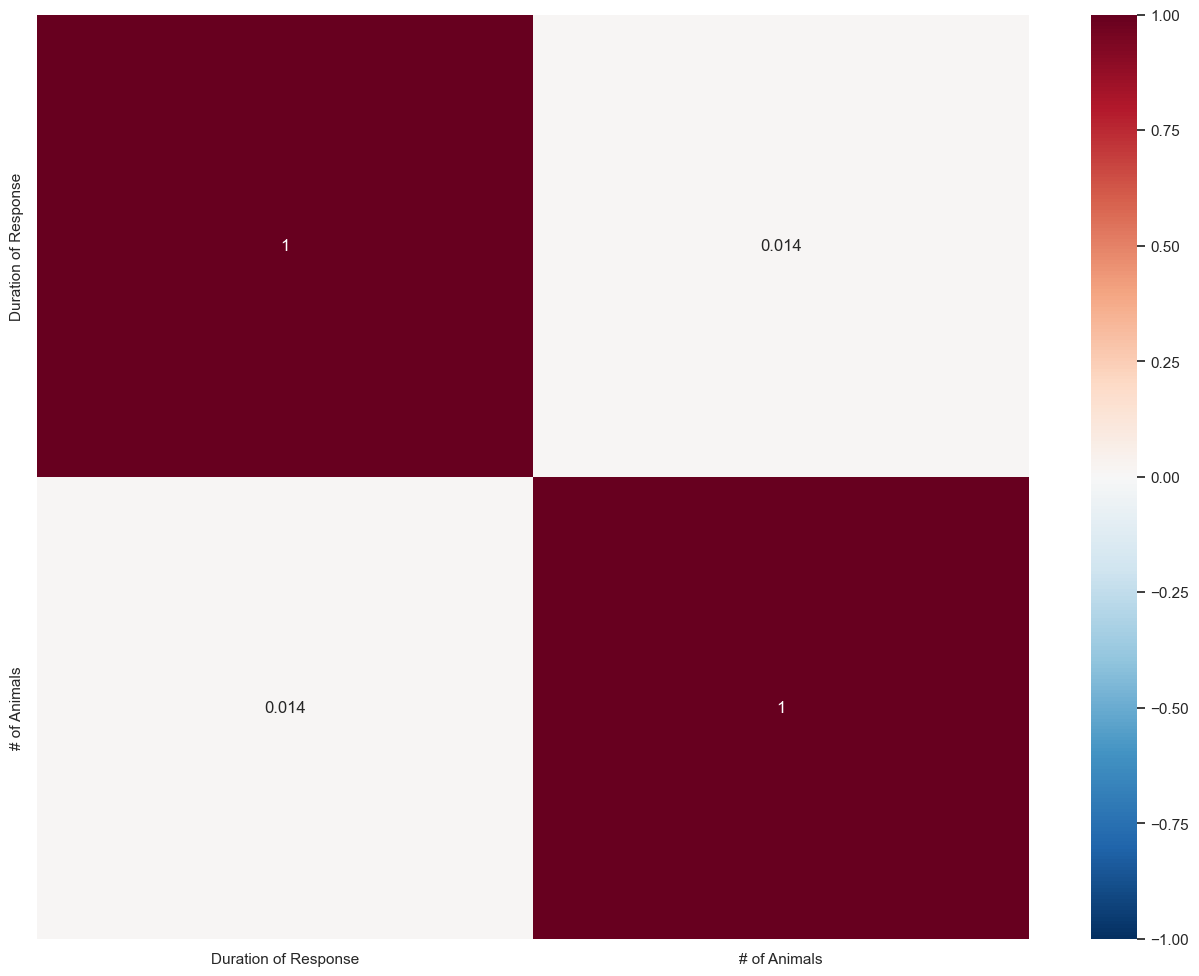

In [1154]:
#HeatMap before Encoding anything, only numerical 
#correlation heat map 
#Shows almost no correlation 
selected_cols= ['Duration of Response','# of Animals',  ]
df_selected=df[selected_cols]
corr = df_selected.corr(method='spearman')
sns.set(font_scale=1)
plt.figure(figsize=(16,12))
sns_plot = sns.heatmap(
    corr,        
    cmap='RdBu_r', 
    annot=True, 
    vmin=-1, vmax=1);

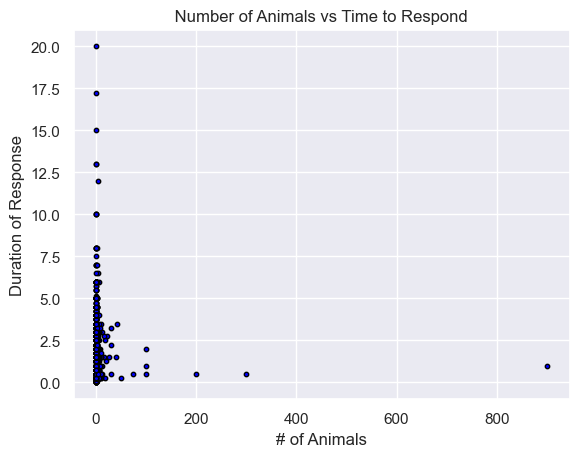

In [1095]:
#scatterplot: duration of response vs number of animals

x = df['# of Animals']
y = df['Duration of Response']

plt.scatter(x, y, color='blue', marker='o', s=10, edgecolors='black')

plt.title(' Number of Animals vs Time to Respond ')
plt.xlabel('# of Animals')
plt.ylabel('Duration of Response')

plt.grid(True)
plt.show()


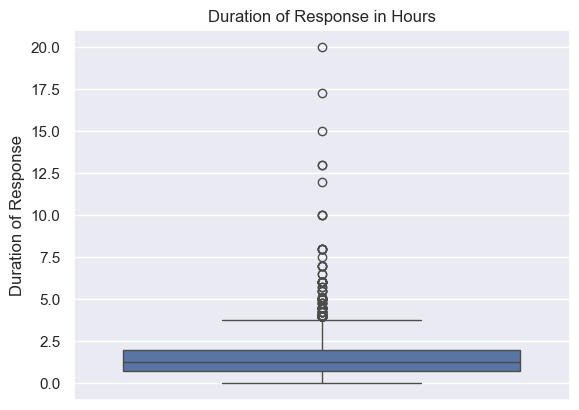

In [1098]:
#boxplot showing distribution of duration of response.
sns.boxplot(df["Duration of Response"])
plt.title("Duration of Response in Hours")
plt.show()


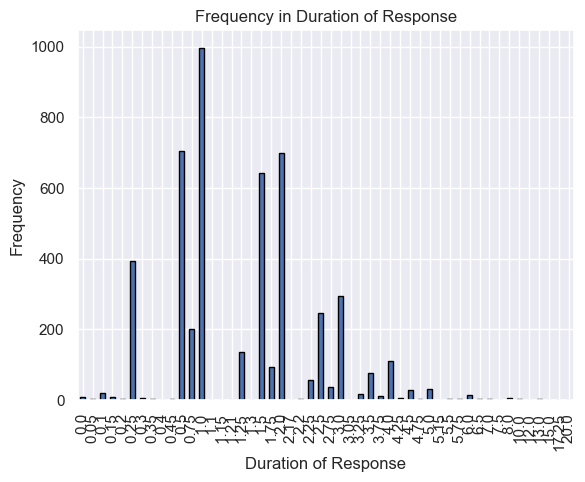

In [1099]:
column_name = 'Duration of Response'

df[column_name].value_counts().sort_index().plot(kind='bar', edgecolor='black')

plt.title(f'Frequency in {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


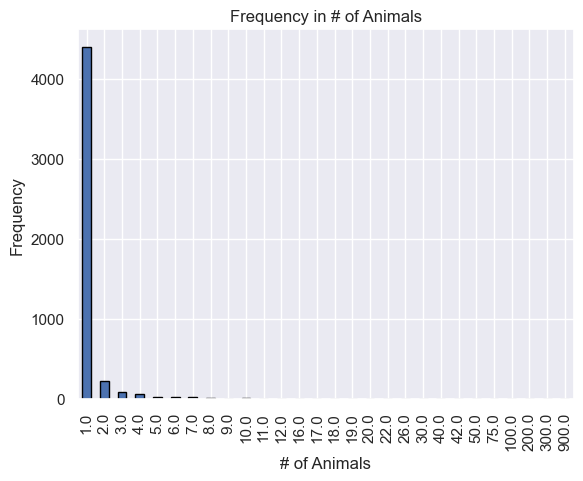

In [1101]:
# Histogram
column_name = '# of Animals'

df[column_name].value_counts().sort_index().plot(kind='bar', edgecolor='black')

plt.title(f'Frequency in {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


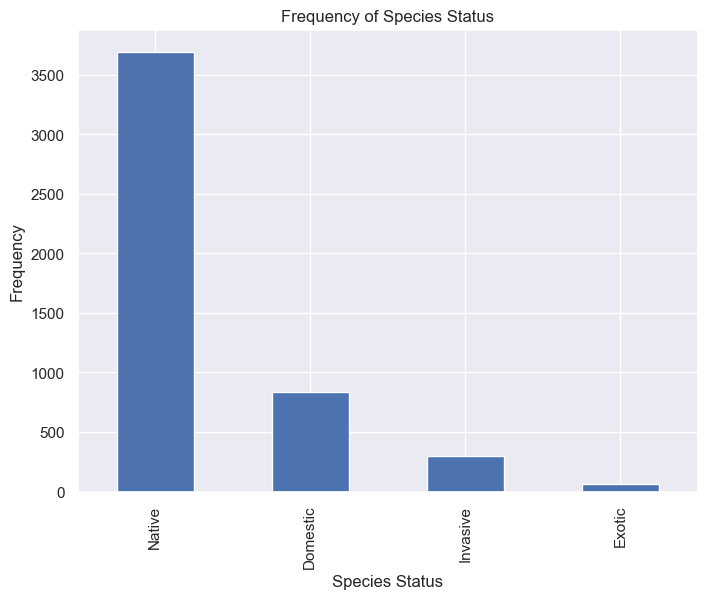

In [1104]:
#bar chart with the categorical variable - Species status. 
category_counts = df['Species Status'].value_counts()

# Plot using matplotlib
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Frequency of Species Status')
plt.xlabel('Species Status')
plt.ylabel('Frequency')
plt.show()


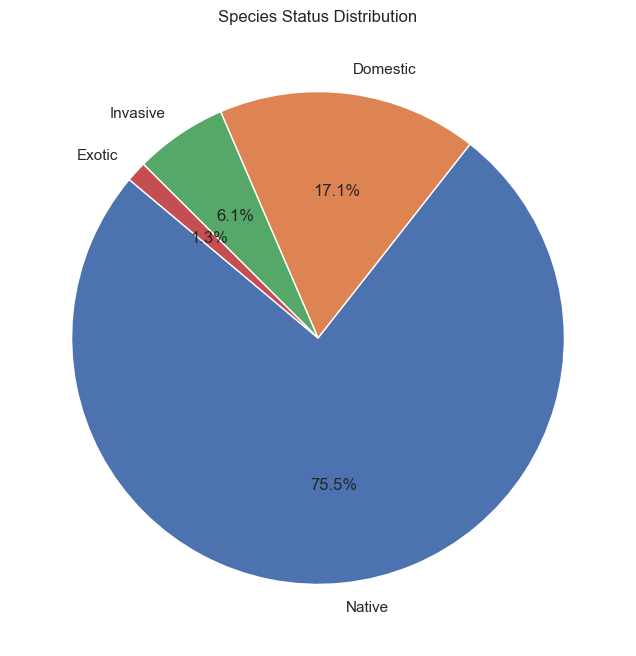

In [1106]:
#bar chart with the categorical variable - Species status.
category_counts = df['Species Status'].value_counts()

plt.figure(figsize=(8, 8))
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Species Status Distribution')
plt.ylabel('')  # Hide the y-axis label
plt.show()

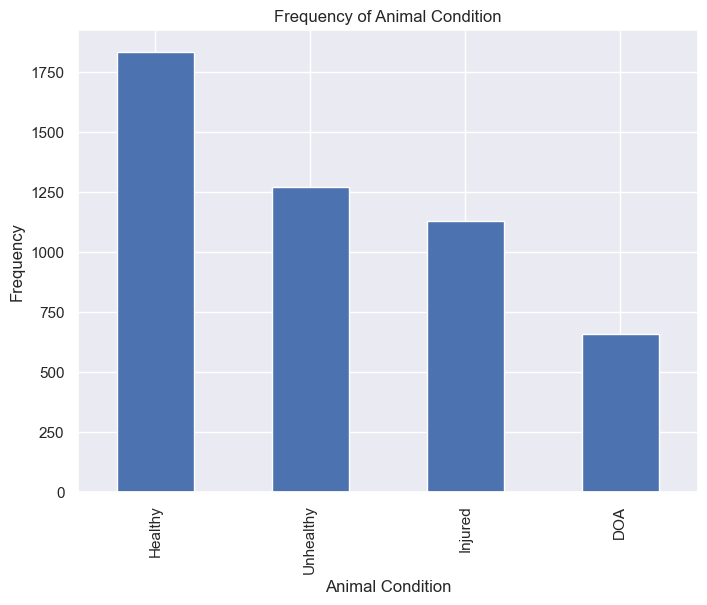

In [1108]:
#bar chart with the categorical variable - Animal Condition. 
category_counts = df['Animal Condition'].value_counts()

# Plot using matplotlib
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar')
plt.title('Frequency of Animal Condition')
plt.xlabel('Animal Condition')
plt.ylabel('Frequency')
plt.show()

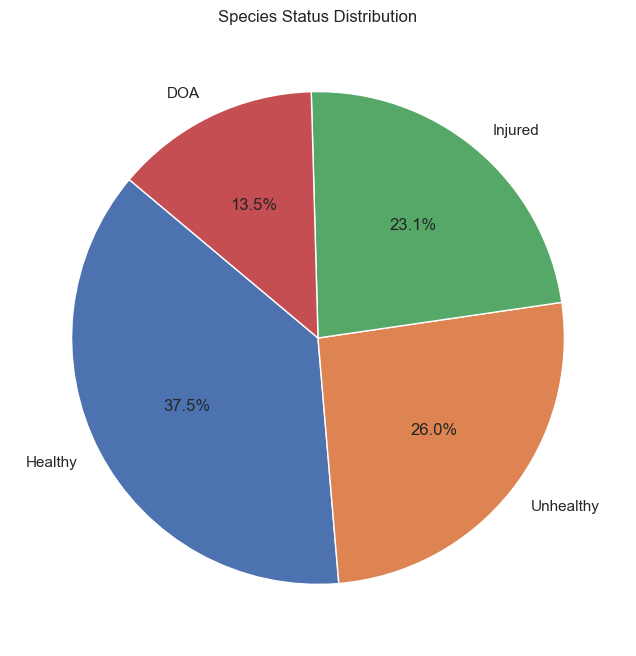

In [1109]:
#bar chart with the categorical variable - Species status.
category_counts = df['Animal Condition'].value_counts()

plt.figure(figsize=(8, 8))
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Species Status Distribution')
plt.ylabel('')  # Hide the y-axis label
plt.show()

In [1110]:
#encoding independent variables
df['Animal Condition'].unique()

array(['Healthy', 'Injured', 'Unhealthy', 'DOA'], dtype=object)

In [1114]:
df['Species Status'].unique()

array(['Exotic', 'Native', 'Domestic', 'Invasive'], dtype=object)

In [1115]:
#keeping this as categorical, not encoding this. 
df['Species Description'].unique()

array(['Chukar', 'Sparrow', 'Virginia Opossum', 'Domestic Duck', 'Dog',
       'Eastern Rat Snake', 'Eastern Gray Squirrel', 'Northern Cardinal',
       'Mallard Duck', 'Double-crested Cormorant',
       'Common Snapping Turtle', 'Chicken',
       'Argentine Black and White Tegu', 'Raccoon', 'American Kestrel',
       'Red-tailed Hawk', 'Cat', 'Canada Goose', 'Rock Dove', 'Catfish',
       'Red-Eared Slider', 'Bat (Unknown)', 'Common Grackle',
       'Herring Gull', 'Laughing Gull', 'Diamondback Terrapin',
       'Blue Jay', 'Barn Swallow', 'Mute Swan', 'Wood Duck',
       'Spiny Softshell Turtle', 'Warbling Vireo', 'Brant Goose',
       'House Sparrow', 'American Robin', 'Eastern Box Turtle',
       'Bearded Dragon', 'White-tailed Deer', 'Bird (Unknown)',
       'Painted Turtle', 'Corn Snake', 'Domestic Turkey',
       'European Starling', 'Ovenbird', 'Ring-billed Gull',
       'Rose-breasted Grosbeak', 'Muskrat', 'Domestic Rabbit',
       'Great Black-backed Gull', 'Yellow-bellied Sl

In [1118]:
df['Age'].unique()

array(['Adult', 'Infant', 'Juvenile', 'Adult;#Juvenile', 'Adult;#Infant',
       'Adult, Juvenile', 'Adult, Infant', 'Juvenile, Adult',
       'Adult, Juvenile, Infant', 'Adult, Infant, Juvenile',
       'Adult;#Juvenile;#Infant', 'Infant;#Adult', 'Juvenile;#Adult',
       'Infant, Adult', '["Adult"]', '["Juvenile"]', '["Infant"]',
       '["Adult","Juvenile"]', '["Juvenile","Adult"]',
       '["Adult","Infant"]'], dtype=object)

In [1119]:
#cleaning up input inconsistencies. 
df['Age'] = df['Age'].astype(str).str.replace(r'[\[\]"]', '', regex=True)  
df['Age'] = df['Age'].str.replace(';#', ', ')

In [1122]:
df['Age'].unique()
# Not using age, because of too many inconsistencies.

array(['Adult', 'Infant', 'Juvenile', 'Adult, Juvenile', 'Adult, Infant',
       'Juvenile, Adult', 'Adult, Juvenile, Infant',
       'Adult, Infant, Juvenile', 'Infant, Adult', 'Adult,Juvenile',
       'Juvenile,Adult', 'Adult,Infant'], dtype=object)

In [1123]:
dep_columns = ['Duration of Response']

In [1126]:
df= pd.get_dummies (df, columns=['Animal Condition','Species Status'])
df.head()

,Date and Time of initial call,Date and time of Ranger response,Borough,Property,Location,Species Description,Call Source,Duration of Response,Age,Animal Class,...,ESU Response,ACC Intake Number,Animal Condition_DOA,Animal Condition_Healthy,Animal Condition_Injured,Animal Condition_Unhealthy,Species Status_Domestic,Species Status_Exotic,Species Status_Invasive,Species Status_Native
0,06/23/2021 04:45:00 PM,06/24/2021 08:00:00 AM,Brooklyn,Sternberg Park,Inside locked athletic field under construction,Chukar,Other,6.00,Adult,Birds,...,False,163537,False,True,False,False,False,True,False,False
1,06/24/2021 10:00:00 AM,06/24/2021 11:00:00 AM,Bronx,Haffen Park,Haffen Pool,Sparrow,Central,1.75,Infant,Birds,...,False,NaN,False,True,False,False,False,False,False,True
4,06/23/2021 09:20:00 AM,06/23/2021 09:20:00 AM,Queens,Judge Moses Weinstein Playground,Garbage can,Virginia Opossum,Central,2.25,Juvenile,Small Mammals-non RVS,...,False,119833,False,True,False,False,False,False,False,True
5,06/23/2021 09:00:00 AM,06/23/2021 09:10:00 AM,Staten Island,Clove Lakes Park,Martling Pond on shore,Domestic Duck,Employee,1.25,Adult,Domestic;#Birds,...,False,119822,False,True,False,False,True,False,False,False
8,06/22/2021 03:30:00 PM,06/22/2021 03:30:00 PM,Brooklyn,Prospect Park,V/O Drummers Circle,Dog,Employee,0.50,Juvenile,Domestic,...,False,NaN,False,False,True,False,True,False,False,False


In [1128]:
ind_columns=['Animal Condition_DOA','Animal Condition_Healthy','Animal Condition_Injured','Animal Condition_Unhealthy','Species Status_Domestic','Species Status_Exotic','Species Status_Invasive','Species Status_Native']


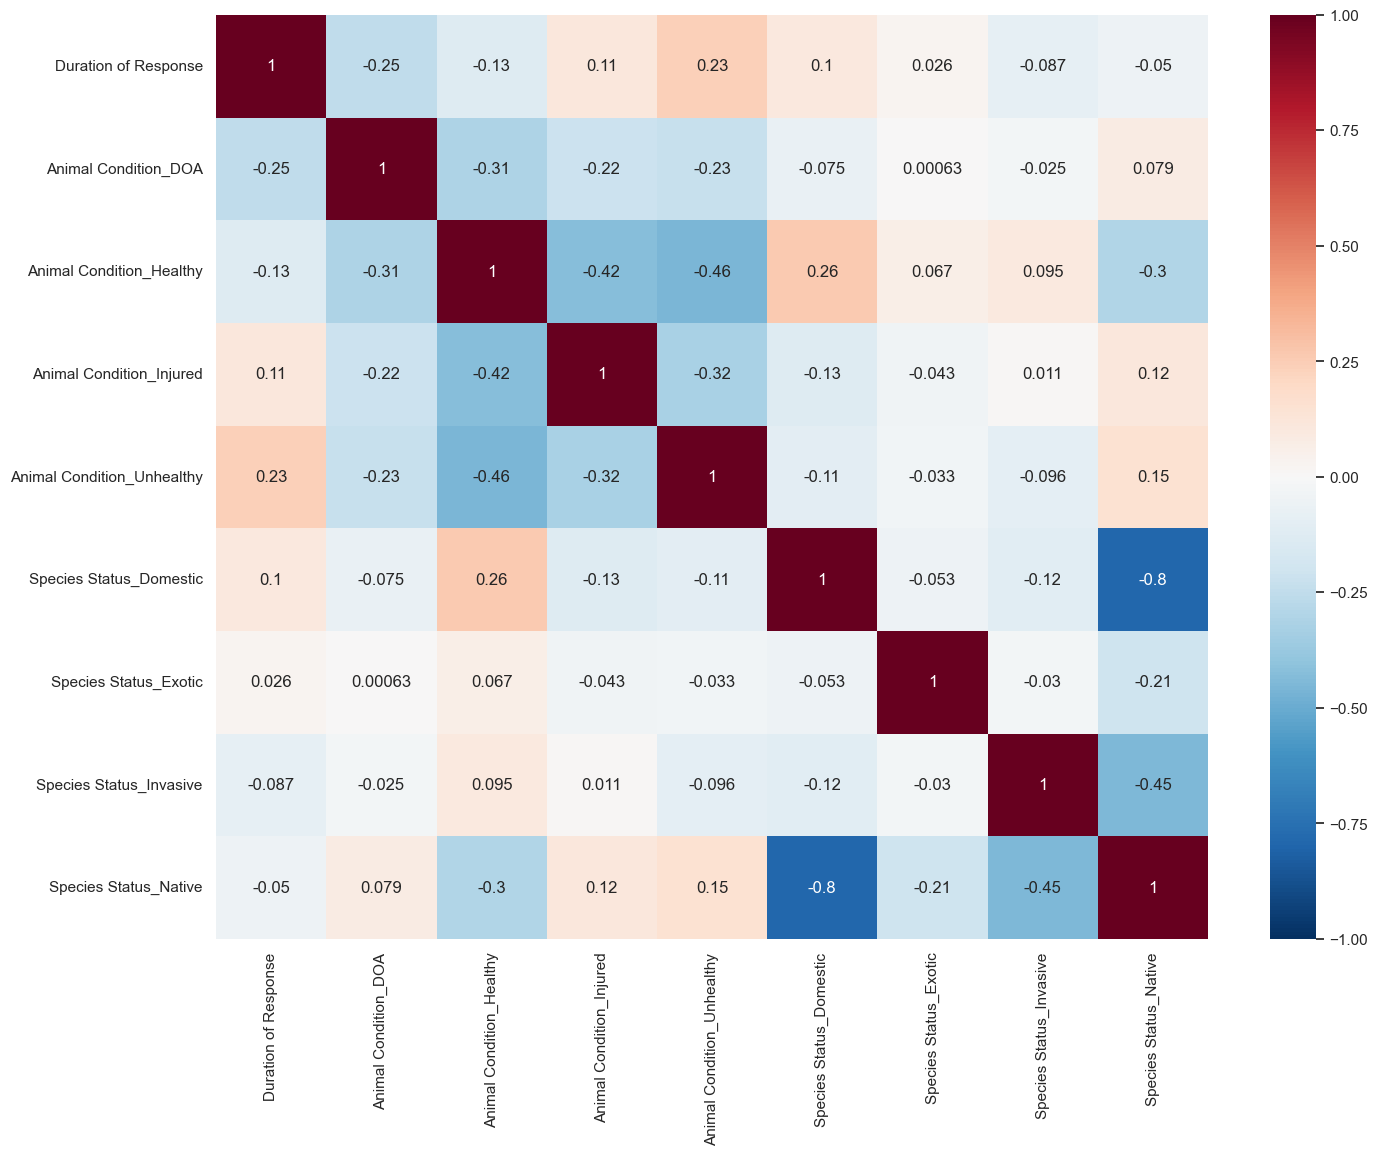

In [1130]:
#correlation heat map with categorical

selected_cols= dep_columns +ind_columns
df_selected=df[selected_cols]
corr = df_selected.corr(method='spearman')
sns.set(font_scale=1)
plt.figure(figsize=(16,12))
sns_plot = sns.heatmap(
    corr,        
    cmap='RdBu_r', 
    annot=True, 
    vmin=-1, vmax=1);

In [1132]:
#Calculating correlations of 'Duration of Response'
abs_corr = df_selected.corr()['Duration of Response'].apply(lambda x: abs(x))
abs_corr.sort_values(ascending=False, inplace=True)
abs_corr.drop(index='Duration of Response', axis=1, inplace=True)
abs_corr

Animal Condition_DOA          0.172782
Animal Condition_Unhealthy    0.151746
Animal Condition_Healthy      0.082968
Animal Condition_Injured      0.077277
Species Status_Domestic       0.071071
Species Status_Invasive       0.062395
Species Status_Exotic         0.048617
Species Status_Native         0.040557
Name: Duration of Response, dtype: float64

In [1134]:
#Calculating correlations for domestic animals and their health
condition=['Animal Condition_DOA','Animal Condition_Healthy','Animal Condition_Injured','Animal Condition_Unhealthy', 'Species Status_Domestic']
df_condition= df[condition]
abs_corr = df_condition.corr()['Species Status_Domestic'].apply(lambda x: abs(x))
abs_corr.sort_values(ascending=False, inplace=True)
abs_corr.drop(index='Species Status_Domestic', axis=1, inplace=True)
abs_corr

Animal Condition_Healthy      0.260149
Animal Condition_Injured      0.127463
Animal Condition_Unhealthy    0.106084
Animal Condition_DOA          0.075200
Name: Species Status_Domestic, dtype: float64

In [1136]:
#Calculating correlations for native animals and their health
condition=['Animal Condition_DOA','Animal Condition_Healthy','Animal Condition_Injured','Animal Condition_Unhealthy', 'Species Status_Native']
df_condition= df[condition]
abs_corr = df_condition.corr()['Species Status_Native'].apply(lambda x: abs(x))
abs_corr.sort_values(ascending=False, inplace=True)
abs_corr.drop(index='Species Status_Native', axis=1, inplace=True)
abs_corr

Animal Condition_Healthy      0.298343
Animal Condition_Unhealthy    0.154902
Animal Condition_Injured      0.117073
Animal Condition_DOA          0.079490
Name: Species Status_Native, dtype: float64

In [1137]:
#Calculating correlations for invasive animals and their health
condition=['Animal Condition_DOA','Animal Condition_Healthy','Animal Condition_Injured','Animal Condition_Unhealthy', 'Species Status_Invasive']
df_condition= df[condition]
abs_corr = df_condition.corr()['Species Status_Invasive'].apply(lambda x: abs(x))
abs_corr.sort_values(ascending=False, inplace=True)
abs_corr.drop(index='Species Status_Invasive', axis=1, inplace=True)
abs_corr

Animal Condition_Unhealthy    0.095909
Animal Condition_Healthy      0.095079
Animal Condition_DOA          0.024979
Animal Condition_Injured      0.010805
Name: Species Status_Invasive, dtype: float64

In [1138]:
#Calculating correlations for exotic animals and their health
condition=['Animal Condition_DOA','Animal Condition_Healthy','Animal Condition_Injured','Animal Condition_Unhealthy', 'Species Status_Exotic']
df_condition= df[condition]
abs_corr = df_condition.corr()['Species Status_Exotic'].apply(lambda x: abs(x))
abs_corr.sort_values(ascending=False, inplace=True)
abs_corr.drop(index='Species Status_Exotic', axis=1, inplace=True)
abs_corr

Animal Condition_Healthy      0.066922
Animal Condition_Injured      0.043130
Animal Condition_Unhealthy    0.032889
Animal Condition_DOA          0.000628
Name: Species Status_Exotic, dtype: float64

In [1170]:

#multiple regression model 

cols = [ 'Animal Condition_DOA',
        'Animal Condition_Unhealthy',
        'Animal Condition_Healthy',
        'Animal Condition_Injured',
        'Species Status_Domestic',
        #'Species Status_Native', 
        '# of Animals',
         
       # 'Species Status_Exotic', 
       # 'Species Status_Invasive' 
         
       ]
df_model = df[['Duration of Response']+cols].dropna()

def do_regression(X_train, X_test, y_train, y_test):
    # Fit a least squares regression model
    linModel = LinearRegression()
    linModel.fit(X_train, y_train)
    yPredicted = linModel.predict(X_train)
    print('Training r_squared value: ',linModel.score(X_train,y_train))
    print('Testing r_squared value: ', linModel.score(X_test, y_test))
    # Compute the sum of squared errors for the least squares model
    SSEreg = sum((y_train - yPredicted) ** 2)   #[0]
    print('SSE of Regression: ', SSEreg)
    # Compute the sum of squared errors for the horizontal line model
    SSEyBar = sum((y_train - np.mean(y_train)) ** 2)  #[0]
    print('SSE of mean: ', SSEyBar)
    dfn = 1.0                            # the y-intercept
    dfd = y_train.shape[0] - len(cols) + 1
    F_stat = ((SSEyBar - SSEreg) / (dfn) / (SSEreg / dfd ))
    print('F statistic: ', F_stat)
    p_value = 1 -f.cdf(F_stat, dfn, dfd)
    print('p-value: ', p_value, '\n')
    print(type(yPredicted))
    return p_value

In [1184]:
SL = 0.05
# Extract X and y AFTER dropping NaNs
X = df_model[cols]
y = df_model['Duration of Response']

print('X shape:', X.shape)
print('y shape:', y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.18, random_state=42)
p_value = do_regression(X_train, X_test, y_train, y_test)
while True:
    p_value = do_regression(X_train, X_test, y_train, y_test)
    if p_value > SL:
        break
    else:
        print ("not greater")
        break


X shape: (4891, 6)
y shape: (4891,)
Training r_squared value:  0.05396566587761864
Testing r_squared value:  0.10133705423485806
SSE of Regression:  5653.162656979442
SSE of mean:  5975.642165486284
F statistic:  228.4615727402378
p-value:  1.1102230246251565e-16 

<class 'numpy.ndarray'>
Training r_squared value:  0.05396566587761864
Testing r_squared value:  0.10133705423485806
SSE of Regression:  5653.162656979442
SSE of mean:  5975.642165486284
F statistic:  228.4615727402378
p-value:  1.1102230246251565e-16 

<class 'numpy.ndarray'>
not greater
